In [1]:
import pandas as pd
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt

# 0. Varibales

In [2]:
# Train Headway (min)
train_headway_list = [10, 20, 30]

# MoD Fleet Size
mod_fleet_size_list = [30, 50, 70, 90, 110, 130, 150]

# MaaS Platform Communication Strategy
maas_communication_strategy_list = ['default', 'TPCS']

# Random Seed
random_seed_list = [3, 6, 9]

# MoD Waiting Time Threshold (s)
mod_waiting_time_threshold_list = [300, 600, 900]
# MoD Detour Time Threshold (%)
mod_detour_time_threshold_list = [30, 60, 90]

# Demand Size
demand_size_list = [i for i in range(100, 1001, 100)]
# Demand Split Ratio (Intra Modal, %)
demand_split_ratio_list = [0, 20, 40, 60, 80]

# Total Simulation Time (s)
total_sim_time = [0, 10800]  # 3 hours
# Warm-up Time (s)
warmup_time = 3600  # 1 hour
# Simulation Time Period (s)
time_period = [warmup_time, total_sim_time[1]+warmup_time]  # 1h + 3h

name_dict = {
    'random_seed': "Random Seed", 
    'fleet_size': "Fleet Size",
    'demand_size': "Demand Size",
    'intra_ratio': "Intra Demand Ratio",
    'op_max_detour_time_factor': "Max Detour Time Factor",
    'op_max_wait_time': "Max Wait Time",
    'train_headway': "Train Headway",
    'average_journey_time': "Average Journey Time",
    'average_intercity_journey_time': "Average Intercity Journey Time",
    'average_intracity_journey_time': "Average Intracity Journey Time",
    'average_journey_time_extended': "Average Journey Time (Extended)",
    'average_intercity_journey_time_extended': "Average Intercity Journey Time (Extended)",
    'average_intracity_journey_time_extended': "Average Intracity Journey Time (Extended)",
    'average_amod_service_rate': "Average AMoD Service Rate",
    'total_amod_cost': "Total AMoD Cost",
    'broker_type': "MaaS Communication Strategy",
    'fleet_utilization_rate': "Fleet Utilization Rate",
}

amod_request_level_analysis_folder = "data/amod-sim-results"

SERVICE_RATE_THRESHOLD = 0.80

# 1. Preprocess AMoD Scenario Level Results File

In [3]:
# Read scenario level results file
all_amod_scenario_level_analysis_results_file = os.path.join(amod_request_level_analysis_folder, "all_amod_scenario_level_analysis_results.csv")

all_amod_scenario_level_analysis_results_df = pd.read_csv(all_amod_scenario_level_analysis_results_file)

print(all_amod_scenario_level_analysis_results_df.columns)
print(all_amod_scenario_level_analysis_results_df.shape)

amod_sce_res_df = all_amod_scenario_level_analysis_results_df.copy()

Index(['fleet_utilization_rate', 'distance_avg_occupancy', 'total_km_driven',
       'average_km_driven', 'total_amod_cost', 'average_amod_cost',
       'total_amod_fix_cost', 'total_amod_variable_cost',
       'total_co2_emissions_g', 'total_external_emission_costs',
       'average_amod_service_rate', 'average_intercity_service_rate',
       'average_intracity_service_rate', 'average_journey_time',
       'average_journey_time_extended', 'average_pt_waiting_time',
       'average_intercity_journey_time',
       'average_intercity_journey_time_extended',
       'average_intracity_journey_time',
       'average_intracity_journey_time_extended', 'random_seed', 'fleet_size',
       'demand_size', 'intra_ratio', 'broker_type',
       'op_max_detour_time_factor', 'op_max_wait_time', 'train_headway',
       'scenario_name'],
      dtype='object')
(56700, 29)


### 1.1 Aggregation over random seeds

In [4]:
# Drop scenario name column
amod_sce_res_df = amod_sce_res_df.drop(columns=['scenario_name'])

# Aggregation over random seeds
experiment_vars = [
    'fleet_size', 'demand_size', 'intra_ratio', 'broker_type',
    'op_max_detour_time_factor', 'op_max_wait_time', 'train_headway'
]

metrics_to_avg = [
    'fleet_utilization_rate', 'distance_avg_occupancy', 'total_km_driven',
    'average_km_driven', 'total_amod_cost', 'average_amod_cost',
    'total_amod_fix_cost', 'total_amod_variable_cost',
    'total_co2_emissions_g', 'total_external_emission_costs',
    'average_amod_service_rate', 'average_intercity_service_rate',
    'average_intracity_service_rate', 'average_journey_time',
    'average_journey_time_extended', 'average_pt_waiting_time',
    'average_intercity_journey_time',
    'average_intercity_journey_time_extended',
    'average_intracity_journey_time',
    'average_intracity_journey_time_extended'
]

amod_sce_res_df = (
    amod_sce_res_df
    .groupby(experiment_vars)[metrics_to_avg]
    .mean()
    .reset_index()
)

print("Aggregated shape:", amod_sce_res_df.shape)

Aggregated shape: (18900, 27)


### 1.2 Service rate control

In [5]:
# Drop scenarios that do not meet the service rate threshold
amod_sce_res_df = amod_sce_res_df[
    amod_sce_res_df['average_amod_service_rate'] >= SERVICE_RATE_THRESHOLD
]

print("Filtered shape:", amod_sce_res_df.shape)

Filtered shape: (13733, 27)


### 1.3 Filter

In [6]:
# TPCS only
amod_sce_res_df = amod_sce_res_df[amod_sce_res_df['broker_type'] == 'TPCS']
print("TPCS shape:", amod_sce_res_df.shape)

# Exclude demand_size: 100, 300, 500, 700, 900
amod_sce_res_df = amod_sce_res_df[~amod_sce_res_df['demand_size'].isin([100, 300, 500, 700, 900])]
print("After excluding demand size, shape:", amod_sce_res_df.shape)

# Exclude split ratio: 20, 60
amod_sce_res_df = amod_sce_res_df[~amod_sce_res_df['intra_ratio'].isin([20, 60])]
print("After excluding split ratio, shape:", amod_sce_res_df.shape)

TPCS shape: (7155, 27)
After excluding demand size, shape: (3464, 27)
After excluding split ratio, shape: (2058, 27)


### 1.4 Convert metrics

In [7]:
# Convert seconds to minutes for time-related metrics
time_metrics = [
    'average_journey_time', 'average_journey_time_extended',
    'average_pt_waiting_time',
    'average_intercity_journey_time', 'average_intercity_journey_time_extended',
    'average_intracity_journey_time', 'average_intracity_journey_time_extended'
    ]
for metric in time_metrics:
    amod_sce_res_df[metric] = amod_sce_res_df[metric] / 60.0

# Convert cent to euro
cost_metrics = [
    'total_amod_cost', 'average_amod_cost',
    'total_amod_fix_cost', 'total_amod_variable_cost',
    'total_external_emission_costs'
    ]
for metric in cost_metrics:
    amod_sce_res_df[metric] = amod_sce_res_df[metric] / 100.0

# 1A. Preprocess PT Scenario Level Results File

In [8]:
# Read PT scenario level results
all_pt_scenario_level_analysis_results_df = pd.read_csv(os.path.join("data/pt-sim-results", "all_pt_scenario_level_analysis_results.csv"))
print(all_pt_scenario_level_analysis_results_df.shape)

pt_sce_res_df = all_pt_scenario_level_analysis_results_df.copy()
print(pt_sce_res_df.columns)

(1800, 11)
Index(['average_journey_time', 'average_pt_service_rate',
       'average_intracity_journey_time', 'average_intercity_journey_time',
       'pt_network_name', 'train_headway', 'bus_headway', 'demand_size',
       'intra_ratio', 'random_seed', 'total_pt_cost'],
      dtype='object')


### 1A.1 Aggregation over random seeds

In [9]:
# Aggregation over random seeds
experiment_vars = [
    'demand_size', 'intra_ratio', 'train_headway',
    'pt_network_name', 'bus_headway',
]

metrics_to_avg = [
    'average_journey_time', 'average_pt_service_rate',
    'average_intracity_journey_time', 'average_intercity_journey_time',
    'total_pt_cost'
]

pt_sce_res_df = (
    pt_sce_res_df
    .groupby(experiment_vars)[metrics_to_avg]
    .mean()
    .reset_index()
)

print("Aggregated shape:", pt_sce_res_df.shape)

Aggregated shape: (600, 10)


### 1A.2 Service rate control

In [10]:
# Drop scenarios that do not meet the service rate threshold
pt_sce_res_df = pt_sce_res_df[
    pt_sce_res_df['average_pt_service_rate'] >= SERVICE_RATE_THRESHOLD
]

print("Filtered shape:", pt_sce_res_df.shape)

Filtered shape: (600, 10)


### 1A.2 Filter

In [11]:
# Exclude demand_size: 100, 300, 500, 700, 900
pt_sce_res_df = pt_sce_res_df[~pt_sce_res_df['demand_size'].isin([100, 300, 500, 700, 900])]
print("After excluding demand size, shape:", pt_sce_res_df.shape)

After excluding demand size, shape: (300, 10)


### 1A.3 Convert metrics

In [12]:
# Convert seconds to minutes for time-related metrics
time_metrics = [
    'average_journey_time',
    'average_intercity_journey_time', 
    'average_intracity_journey_time', 
    ]
for metric in time_metrics:
    pt_sce_res_df[metric] = pt_sce_res_df[metric] / 60.0

# 2. AMoD Pareto Frontier Analysis

In [13]:
def get_pareto_frontier(group_df):
    sorted_df = group_df.sort_values(by='total_amod_cost', ascending=True)
    
    pareto_points = []
    min_time_so_far = float('inf')
    
    for _, row in sorted_df.iterrows():
        if row['average_journey_time_extended'] < min_time_so_far:
            pareto_points.append(row)
            min_time_so_far = row['average_journey_time_extended']
            
    return pd.DataFrame(pareto_points)

In [14]:
env_cols = ['demand_size', 'intra_ratio', 'train_headway']

all_frontiers = []

for env_values, group_data in amod_sce_res_df.groupby(env_cols):
    frontier = get_pareto_frontier(group_data)
    
    all_frontiers.append(frontier)

amod_sce_res_df_pareto_tpcs = pd.concat(all_frontiers)

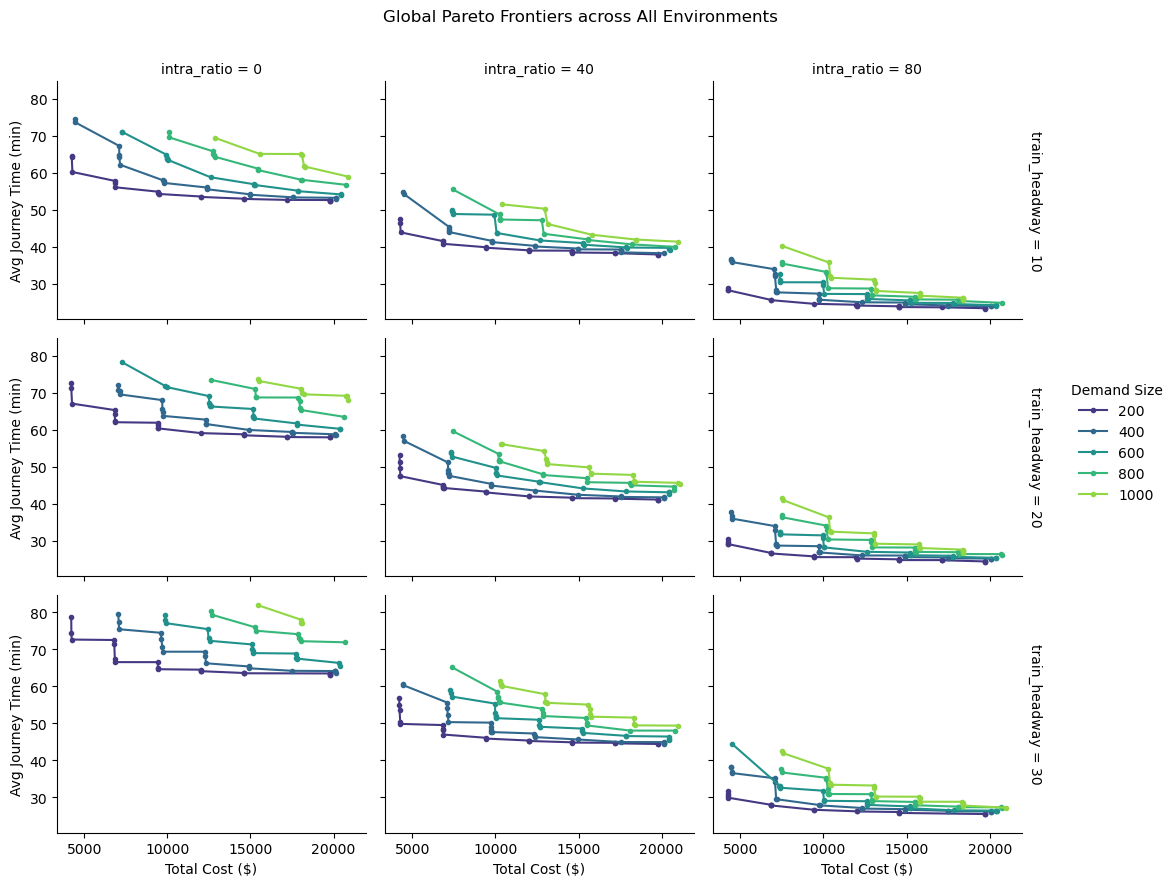

In [21]:
g = sns.FacetGrid(amod_sce_res_df_pareto_tpcs, 
                  row="train_headway", 
                  col="intra_ratio", 
                  hue="demand_size",
                  palette="viridis",
                  margin_titles=True,
                  height=3, aspect=1.2)

g.map(plt.plot, "total_amod_cost", "average_journey_time_extended", marker=".")

g.add_legend(title="Demand Size")

g.set_axis_labels("Total Cost ($)", "Avg Journey Time (min)")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Global Pareto Frontiers across All Environments')
plt.show()

# 2A. Bus Pareto Frontier Analysis

In [16]:
def get_bus_pareto_per_network(df):
    pareto_frames = []
    group_cols = ['train_headway', 'intra_ratio', 'demand_size', 'pt_network_name']
    
    for _, group in df.groupby(group_cols):
        agg_point = group[['total_pt_cost', 'average_journey_time']].mean()
        
        row = group.iloc[0].copy()
        row['total_pt_cost'] = agg_point['total_pt_cost']
        row['average_journey_time'] = agg_point['average_journey_time']
        
        pareto_frames.append(row)
        
    return pd.DataFrame(pareto_frames)

In [17]:
pt_sce_res_df_pareto_tpcs = get_bus_pareto_per_network(pt_sce_res_df)

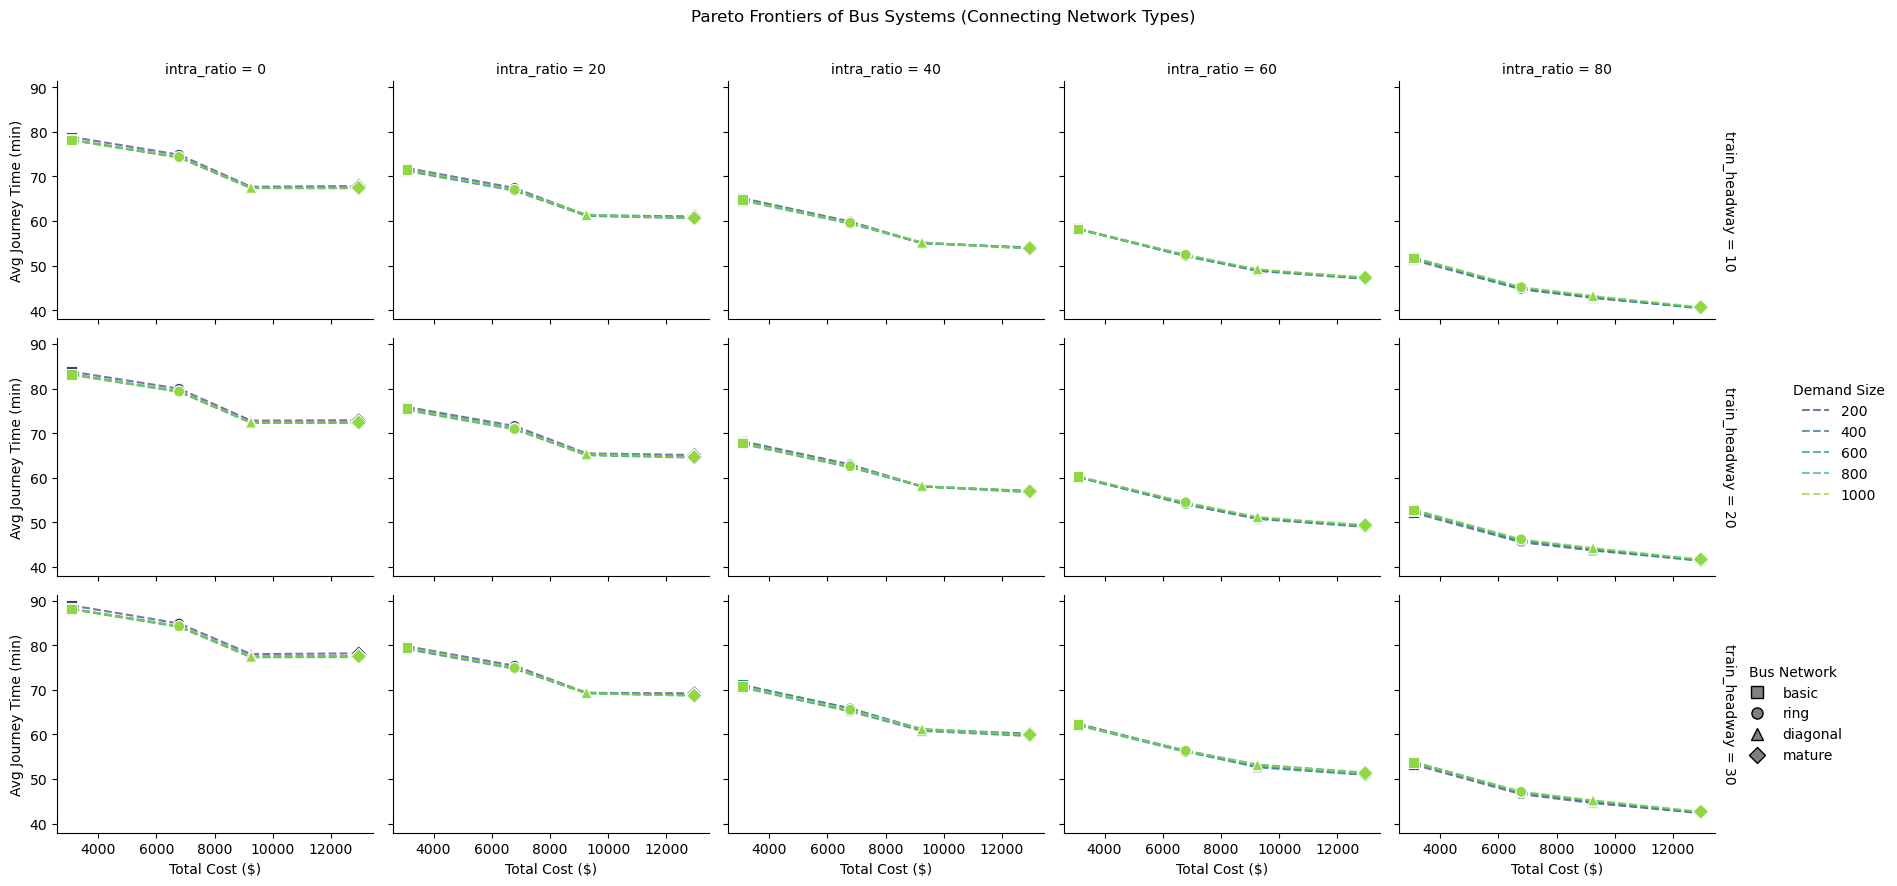

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. 关键预处理：排序
# ==========================================
pt_plot_df = pt_sce_res_df.sort_values(by=['train_headway', 'intra_ratio', 'demand_size', 'total_pt_cost'])

# ==========================================
# 2. 定义形状映射 (可选，但强烈建议)
# ==========================================
# 这样我们可以一眼看出前沿上的这个点是哪种 Bus
# 定义一个辅助函数来画带有形状的散点
def plot_bus_markers(x, y, **kwargs):
    ax = plt.gca()
    data = kwargs.pop('data')
    sns.scatterplot(data=data, x=x, y=y, style='pt_network_name', 
                    markers={'basic': 's', 'ring': 'o', 'diagonal': '^', 'mature': 'D'},
                    s=60, color=kwargs['color'], ax=ax, legend=False, zorder=10)

# ==========================================
# 3. 绘图
# ==========================================
# 使用与 DRT 相同的调色板
unique_demands = sorted(pt_plot_df['demand_size'].unique())
palette = sns.color_palette("viridis", n_colors=len(unique_demands))
palette_dict = dict(zip(unique_demands, palette))

g = sns.FacetGrid(pt_plot_df, 
                  row="train_headway", 
                  col="intra_ratio", 
                  hue="demand_size",
                  palette=palette_dict,
                  margin_titles=True,
                  height=3, aspect=1.2)

# A. 画线 (连接不同 Bus 网络形成的前沿)
# 这一步展示 "随着投入增加，Bus 系统性能提升的路径"
g.map(plt.plot, "total_pt_cost", "average_journey_time", marker=None, linestyle='--', alpha=0.7)

# B. 画点 (区分具体的 Bus 网络类型)
# 使用 map_dataframe 传递完整数据以支持 style 参数
g.map_dataframe(plot_bus_markers, x="total_pt_cost", y="average_journey_time")

# ==========================================
# 4. 装饰与图例
# ==========================================
g.add_legend(title="Demand Size")
g.set_axis_labels("Total Cost ($)", "Avg Journey Time (min)")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Pareto Frontiers of Bus Systems (Connecting Network Types)')

# 手动添加形状图例
from matplotlib.lines import Line2D
marker_map = {'basic': 's', 'ring': 'o', 'diagonal': '^', 'mature': 'D'}
shape_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                        label=name, markersize=8, markeredgecolor='k') 
                 for name, m in marker_map.items()]
plt.legend(handles=shape_handles, title="Bus Network", 
           bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)

plt.show()

# 3. Comparison

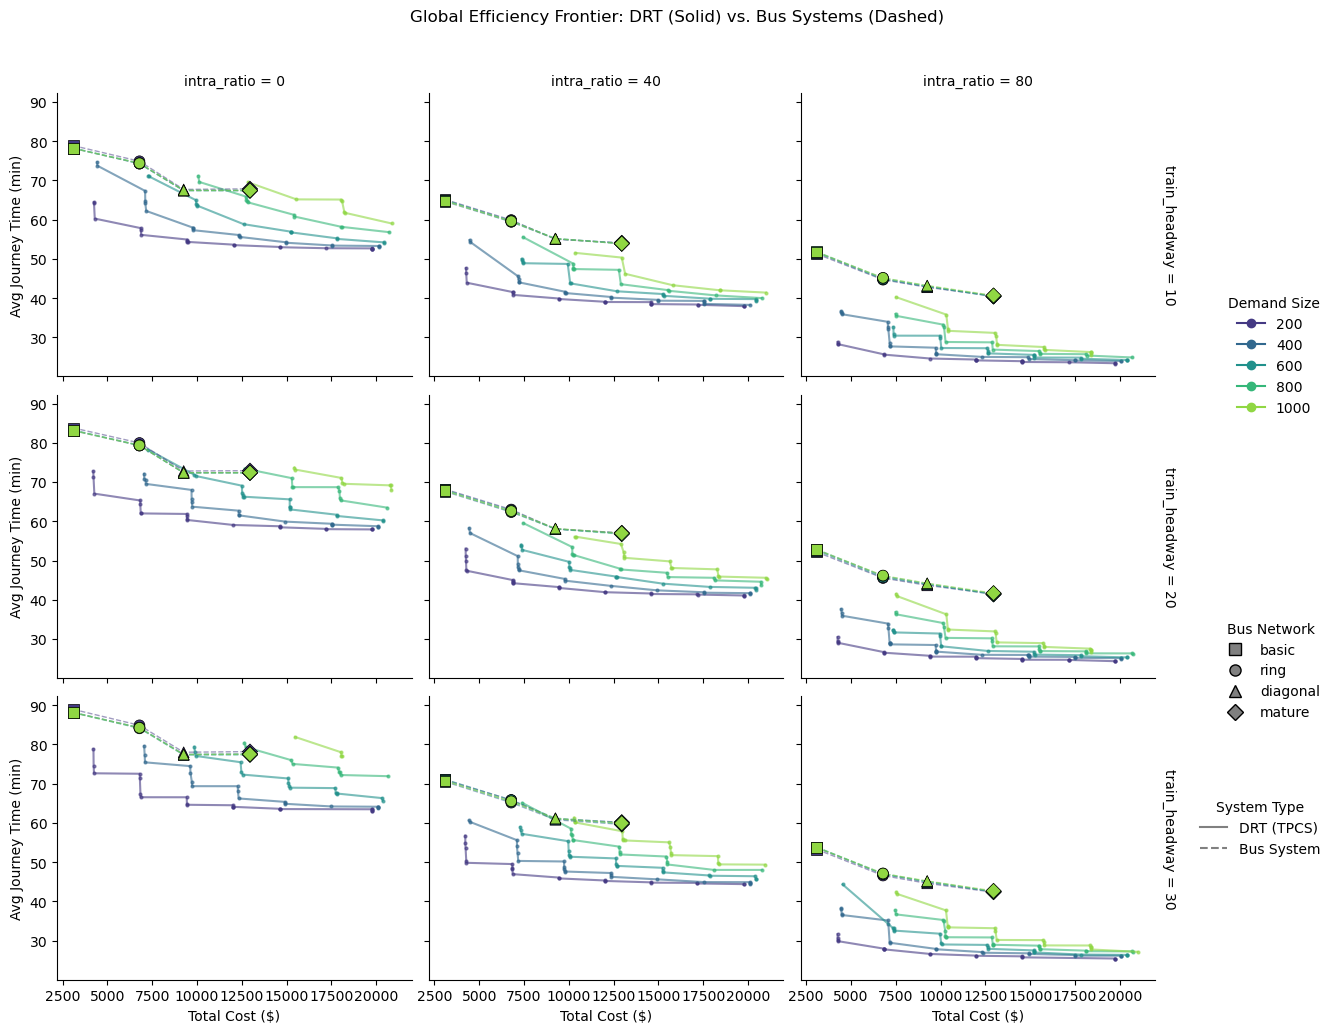

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# ==========================================
# 0. 数据准备与清洗
# ==========================================

# A. 统一颜色映射 (关键步骤)
# 必须确保两个数据集使用完全相同的颜色代表相同的 Demand
# 找出两个数据集中所有的 Demand Size，取并集并排序
all_demands = sorted(list(set(amod_sce_res_df_pareto_tpcs['demand_size']) | set(pt_sce_res_df['demand_size'])))
palette = sns.color_palette("viridis", n_colors=len(all_demands))
palette_dict = dict(zip(all_demands, palette))

# B. Bus 数据预处理
# 1. 聚合：消除随机种子影响，取平均
pt_agg = pt_sce_res_df.groupby(['train_headway', 'intra_ratio', 'demand_size', 'pt_network_name']).mean().reset_index()

# 2. 排序：为了画出漂亮的连线，必须按成本排序
# 逻辑：对于同一个需求，我们想看到随着成本增加（网络升级），时间是如何变化的
pt_sorted = pt_agg.sort_values(by=['train_headway', 'intra_ratio', 'demand_size', 'total_pt_cost'])

# C. 定义 Bus 形状映射
marker_map = {'basic': 's', 'ring': 'o', 'diagonal': '^', 'mature': 'D'}

# ==========================================
# 1. 绘制底层：DRT (TPCS) 前沿
# ==========================================
g = sns.FacetGrid(amod_sce_res_df_pareto_tpcs, 
                  row="train_headway", 
                  col="intra_ratio", 
                  hue="demand_size",
                  palette=palette_dict, # 使用统一的字典
                  margin_titles=True,
                  height=3.5, aspect=1.3)

# 画 DRT 实线
# zorder=1 确保它在底层
g.map(plt.plot, "total_amod_cost", "average_journey_time_extended", 
      marker=".", markersize=4, alpha=0.6, linewidth=1.5, zorder=1)

# ==========================================
# 2. 叠加顶层：Bus 前沿
# ==========================================

# 遍历每一个子图 (ax)
for i, row_val in enumerate(g.row_names): # train_headway
    for j, col_val in enumerate(g.col_names): # intra_ratio
        ax = g.axes[i, j]
        
        # 筛选当前环境下的 Bus 数据
        subset = pt_sorted[
            (pt_sorted['train_headway'] == row_val) & 
            (pt_sorted['intra_ratio'] == col_val)
        ]
        
        if subset.empty:
            continue
            
        # 技巧：按 Demand 分组画线
        # 这一步是为了画出 Bus 的“前沿轨迹” (虚线)
        for demand, group_data in subset.groupby('demand_size'):
            color = palette_dict[demand]
            
            # 画虚线连接不同 Bus 网络 (表示升级路径)
            ax.plot(group_data['total_pt_cost'], group_data['average_journey_time'],
                    color=color, linestyle='--', linewidth=1, alpha=0.5, zorder=2)
            
        # 画散点 (显示具体网络类型)
        sns.scatterplot(
            data=subset,
            x='total_pt_cost',
            y='average_journey_time',
            hue='demand_size',
            style='pt_network_name', # 不同形状代表不同网络
            markers=marker_map,
            palette=palette_dict,    # 强制一致颜色
            s=60,                    # 点的大小
            edgecolor='black',       # 加黑边防止混淆
            linewidth=0.5,
            ax=ax,
            legend=False,            # 关闭自带图例
            zorder=3                 # 确保点在最上层
        )

# ==========================================
# 3. 装饰与图例 (Legend)
# ==========================================

g.set_axis_labels("Total Cost ($)", "Avg Journey Time (min)")
plt.subplots_adjust(top=0.9, right=0.85)
g.fig.suptitle('Global Efficiency Frontier: DRT (Solid) vs. Bus Systems (Dashed)')

# --- 自定义组合图例 ---

# 1. 颜色图例 (Demand Size)
# 只取一部分图例以节省空间 (例如每隔200取一个)
legend_demands = all_demands[::2] if len(all_demands) > 5 else all_demands
color_handles = [
    Line2D([0], [0], color=palette_dict[d], marker='o', linestyle='-', 
           label=f"{d}", markersize=6)
    for d in legend_demands
]
# 添加颜色图例
leg1 = g.fig.legend(handles=color_handles, title="Demand Size",
             bbox_to_anchor=(0.98, 0.65), loc='center right', frameon=False)

# 2. 形状图例 (Bus Network)
shape_handles = [
    Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
           label=name, markersize=8, markeredgecolor='k') 
    for name, m in marker_map.items()
]
# 添加形状图例
g.fig.legend(handles=shape_handles, title="Bus Network",
             bbox_to_anchor=(0.98, 0.35), loc='center right', frameon=False)

# 3. 线型图例 (Line Style)
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-', label='DRT (TPCS)'),
    Line2D([0], [0], color='gray', linestyle='--', label='Bus System')
]
g.fig.legend(handles=style_handles, title="System Type",
             bbox_to_anchor=(0.98, 0.20), loc='center right', frameon=False)

plt.show()